In [1]:
import sqlite3
import pandas
import matplotlib
print("Jupyter is ready!")

Jupyter is ready!


In [13]:
import sqlite3
import random

# Connect to database (creates sales_data.db)
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

# Drop table if it exists
cursor.execute("DROP TABLE IF EXISTS sales")

# Create sales table
cursor.execute("""
    CREATE TABLE sales (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        product TEXT,
        quantity INTEGER,
        price REAL
    )
""")

# Expanded product list with prices
products = {
    "Laptop": 999.99,
    "Phone": 499.99,
    "Tablet": 299.99,
    "Headphones": 49.99,
    "Smartwatch": 199.99,
    "Monitor": 179.99,
    "Keyboard": 49.99,
    "Mouse": 29.99,
    "Charger": 19.99,
    "Webcam": 89.99
}

# Generate 250 rows of sample data
sample_data = [
    (random.choice(list(products.keys())), random.randint(1, 10), products[product])
    for product in random.choices(list(products.keys()), k=250)
]

# Insert data
cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sample_data)
conn.commit()
conn.close()

print("Database created with 250 rows and 10 products!")


Database created with 250 rows and 10 products!


Sales Summary:
      product  total_qty   revenue
0     Charger        152  24088.48
1  Headphones        163  34978.37
2    Keyboard        139  48108.61
3      Laptop        186  50628.14
4     Monitor        180  37358.20
5       Mouse        113  34668.87
6       Phone         87  22349.13
7  Smartwatch        115  23418.85
8      Tablet        129  28258.71
9      Webcam        134  38008.66


<Figure size 576x360 with 0 Axes>

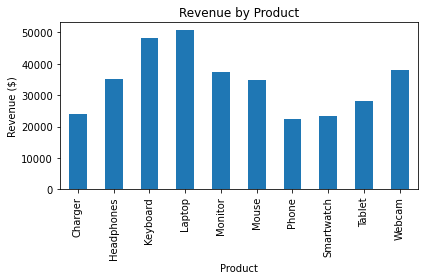

Bar chart saved as sales_chart.png!


In [14]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the database
conn = sqlite3.connect("sales_data.db")

# SQL query for sales summary
query = """
    SELECT product,
           SUM(quantity) AS total_qty,
           SUM(quantity * price) AS revenue
    FROM sales
    GROUP BY product
"""

# Load results into a DataFrame
df = pd.read_sql_query(query, conn)

# Print results
print("Sales Summary:")
print(df)

# Create bar chart
plt.figure(figsize=(8, 5))
df.plot(kind='bar', x='product', y='revenue', legend=False)
plt.title('Revenue by Product')
plt.xlabel('Product')
plt.ylabel('Revenue ($)')
plt.tight_layout()

# Save and show chart
plt.savefig("sales_chart.png")
plt.show()  # Displays chart in notebook
plt.close()

# Close connection
conn.close()

print("Bar chart saved as sales_chart.png!")